# Analyzing Classified Article Data

In this notebook, we will analyze the data obtained from the previous classification step. The classification categorized article abstracts into operational, tactical, and strategic categories using the OpenAI GPT-4o-mini model. We will use tables and graphics to illustrate the research results.

In [2]:
# imports
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

## Loading Classified Data
We will start by loading the classified data from the multiple .csv files created in the previous step. This data includes the original article information along with the classification labels.


In [3]:
def list_files_openai(folder):
    df_all = pd.DataFrame()
    try:
        files = os.listdir(folder)
        for file in files:
            path = os.path.join(folder, file)            
            df = pd.read_csv(path)
            df_all = pd.concat([df_all,df])            
    except Exception as e:
        print(f"Err: {e}")
    return df_all

folder_target = 'data/articles/openai'
df_all = list_files_openai(folder_target)
print(f'Número de Artigos Classificados: {len(df_all)}')
df_all.head()

Número de Artigos Classificados: 2043


,Title,Authors,Year,DOI,Abstract,Keywords,Publisher,Source,Cited,classification,keywords,rationale,Feeling AI,Mechanical AI,Thinking AI,Out of Scope,Not Identified
0,IMPACT OF HORTICULTURE ON THE SUSTAINABLE LIVE...,Mukherjee D.; Jena L.K.; Chakraborty S.; Debna...,2024,10.51599/ARE.2024.10.02.04,Purpose. The perishable nature of the horticul...,economics; horticulture; livelihood developmen...,Institute of Eastern European Research and Con...,scopus-ai,0,Out of Scope,[],The abstract focuses on the horticulture indus...,0%,0%,0%,100%,0%
1,Out of the fog: fog computing-enabled AI to su...,Hornik J.; Ofir C.; Rachamim M.,2024,10.1007/s11301-024-00441-0,Marketing and consumer research use a variety ...,Artificial intelligence (AI); Digital marketin...,Springer Nature,scopus-ai,1,Mechanical AI,"['data deluge', 'IoT systems', 'automation', '...",The abstract discusses the use of IoT devices ...,0%,80%,20%,0%,0%
2,The Role of AI in Enhancing Marketing Communic...,Isnaini S.; Muslimin A.I.,2024,10.11114/smc.v12i4.7013,This research delves into the transformative i...,artificial intelligence; development; higher e...,Redfame Publishing Inc.,scopus-ai,0,Thinking AI,"['Artificial Intelligence', 'marketing communi...",The abstract discusses the use of Artificial I...,10%,30%,60%,0%,0%
3,Deploying artificial intelligence in services ...,Hermann E.; Williams G.Y.; Puntoni S.,2024,10.1007/s11747-023-00986-8,Despite offering substantial opportunities to ...,Artificial intelligence; Ethics; Justice; Serv...,Springer,scopus-ai,11,Feeling AI,"['vulnerable consumers', 'empower', 'accessibl...",The abstract discusses leveraging AI technolog...,70%,10%,20%,0%,0%
4,THE IMPACT OF BRAND-VOICE INTEGRATION AND ARTI...,Murár P.; Kubovics M.; Jurišová V.,2024,10.34135/COMMUNICATIONTODAY.2024.VOL.15.NO.1.4,Corporate identity plays an important role in ...,artificial intelligence; brand communication; ...,"University of SS. Cyril and Methodius, Faculty...",scopus-ai,3,Thinking AI,"['corporate identity', 'brand identity', 'empl...",The abstract discusses the integration of AI i...,10%,10%,80%,0%,0%


In [4]:
df_all['classification'].value_counts()

classification
Thinking AI       1134
Feeling AI         454
Out of Scope       239
Mechanical AI      118
Not Identified      98
Name: count, dtype: int64

## Grouped and saved data
We classified data is saved in grouped .csv will be used for detailed analysis in subsequent our research.

In [5]:
# df_all.to_csv('data/classification/article_classification_gpt4o-mini.csv', index=False)

In [6]:
# for classification in df_all['classification'].unique():    
#     df_all[df_all['classification'] == classification].to_csv(f'data/classification/article_classification_gpt4o-mini_{classification}.csv', index=False)

## Load data from a control point

In [15]:
df_all = pd.read_csv('data/classification/article_classification_gpt4o-mini.csv')
df_all['Year'] = pd.to_numeric(df_all['Year'], errors='coerce')

## Classification Analysis

In [27]:
df_all = df_all[~df_all['classification'].isin(['Out of Scope','Not identified'])]
df_all['classification'].value_counts()

classification
Thinking AI      1134
Feeling AI        454
Mechanical AI     118
Name: count, dtype: int64

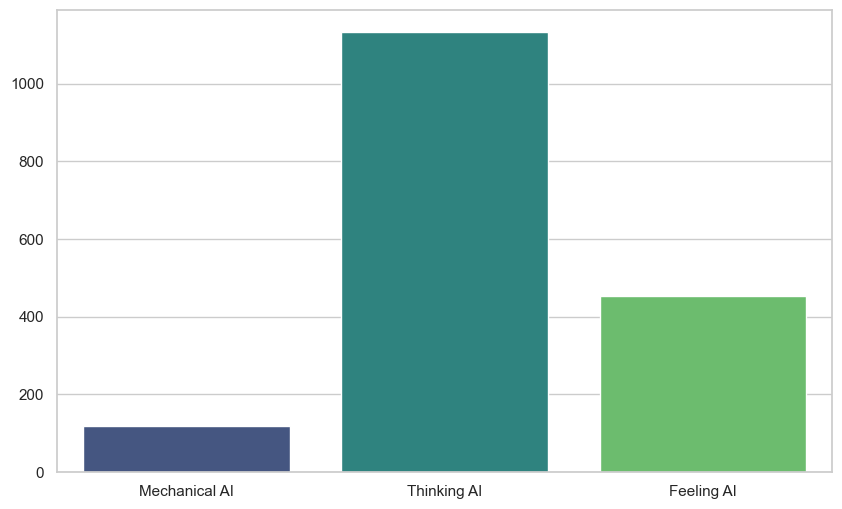

In [28]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(data=df_all, x='classification', palette='viridis')
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

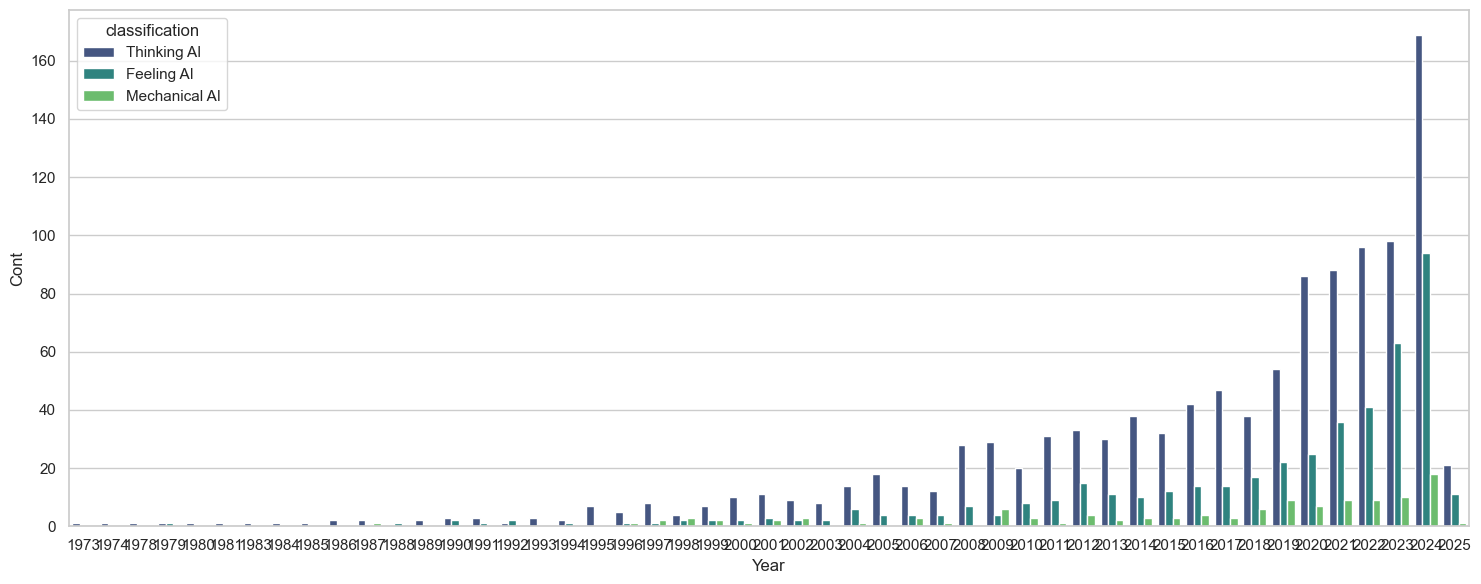

In [29]:
# df_strategic_tactial = df_all[df_all['Classification'].isin(['Strategic', 'Tactical','Operational'])]

fig, axs = plt.subplots(1, 1, figsize=(15, 6))

sns.countplot(data=df_all, x='Year', hue='classification', palette='viridis', ax=axs)
axs.set_title('')
axs.set_xlabel('Year')
axs.set_ylabel('Cont')

plt.tight_layout()
plt.show()

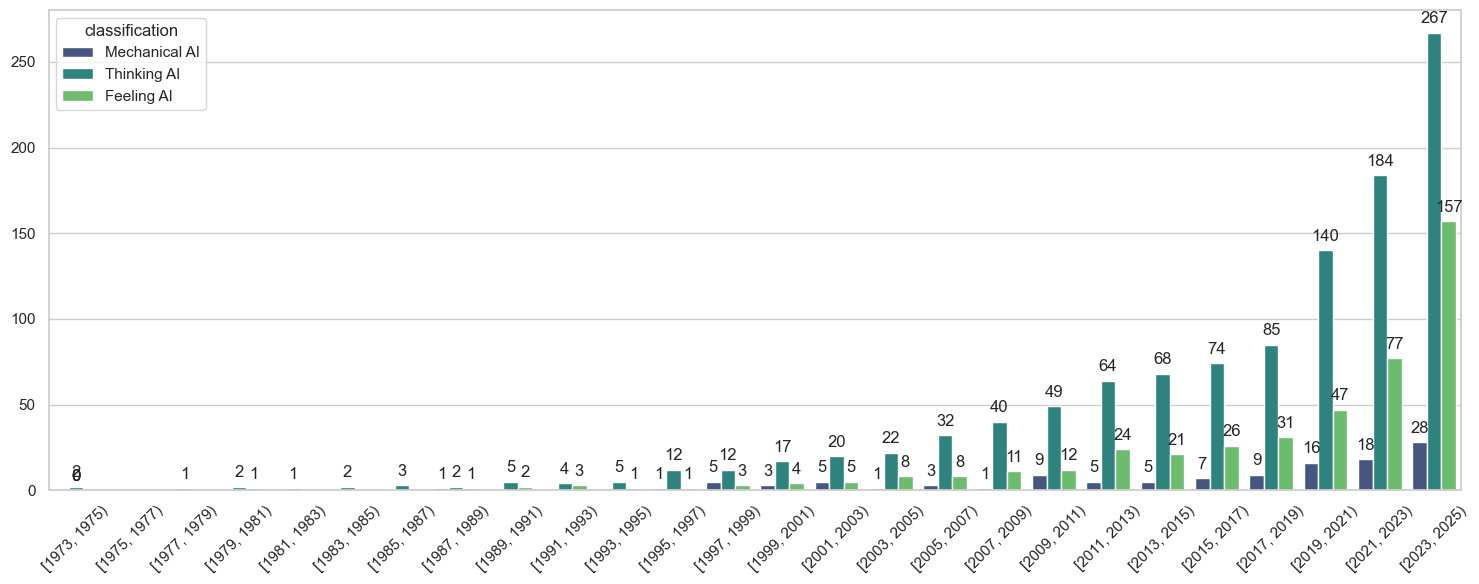

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# df_strategic_tactical = df_all[df_all['Classification'].isin(['Strategic', 'Tactical', 'Operational'])]

df_all['Year_Group'] = pd.cut(df_all['Year'], bins=np.arange(df_all['Year'].min(), df_all['Year'].max() + 2, 2), right=False)
fig, axs = plt.subplots(1, 1, figsize=(15, 6))

ax = sns.countplot(data=df_all, x='Year_Group', hue='classification', palette='viridis', ax=axs)
axs.set_title('')
axs.set_xlabel('')
axs.set_ylabel('')
plt.xticks(rotation=45)  

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()


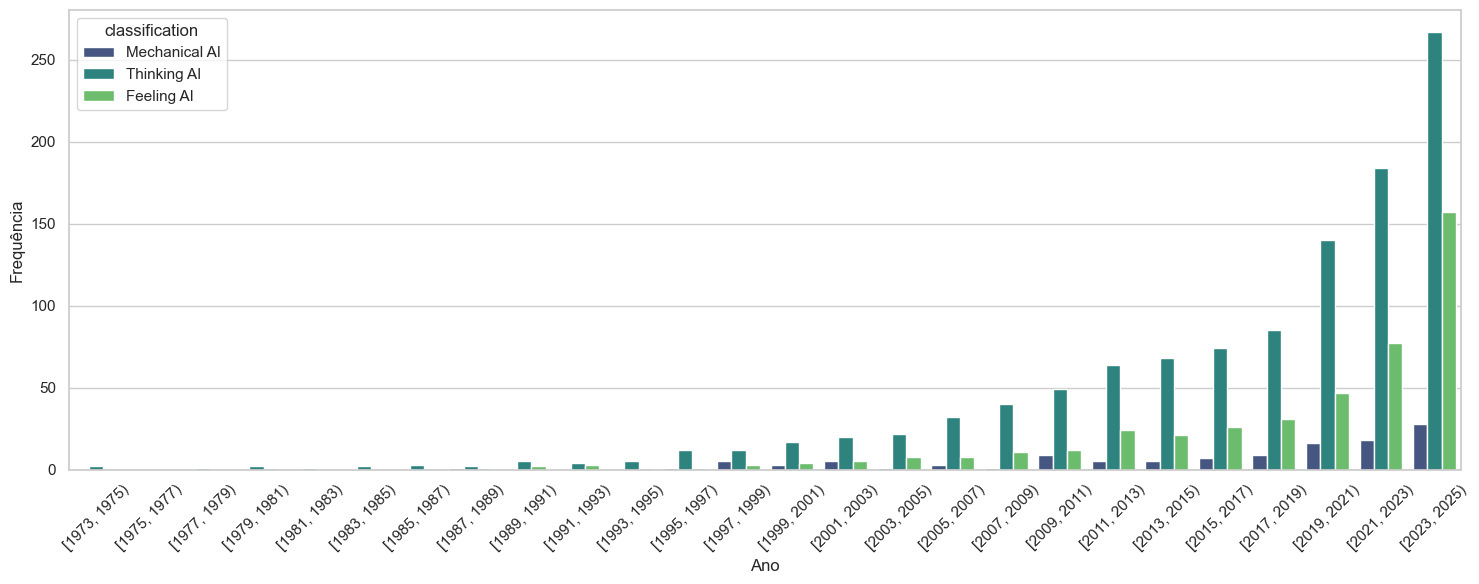

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Agrupar por Year_Group e classification e calcular totais
group_totals = df_all.groupby('Year_Group')['classification'].value_counts(normalize=True).rename('percent').reset_index()

# Plot
fig, axs = plt.subplots(1, 1, figsize=(15, 6))
ax = sns.countplot(data=df_all, x='Year_Group', hue='classification', palette='viridis', ax=axs)

# Adiciona os percentuais sobre as barras
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2.
    year_group = p.get_x() + p.get_width() / 2.

    # Identifica Year_Group e classificação da barra
    group = p.get_x() + p.get_width() / 2.
    year_group = p.get_x() + p.get_width() / 2.
    x_val = p.get_x() + p.get_width() / 2.
    year_group = ax.get_xticks()[int(x_val)]
    classification = p.get_label()

    # Pega percentual calculado
    try:
        percent = group_totals[
            (group_totals['Year_Group'] == p.get_x()) &
            (group_totals['classification'] == p.get_label())
        ]['percent'].values[0]
        text = f'{percent * 100:.1f}%'
    except IndexError:
        text = ''

    ax.annotate(text,
                (x, height),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 5),
                textcoords='offset points')

# Títulos e rótulos
axs.set_title('')
axs.set_xlabel('Ano')
axs.set_ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

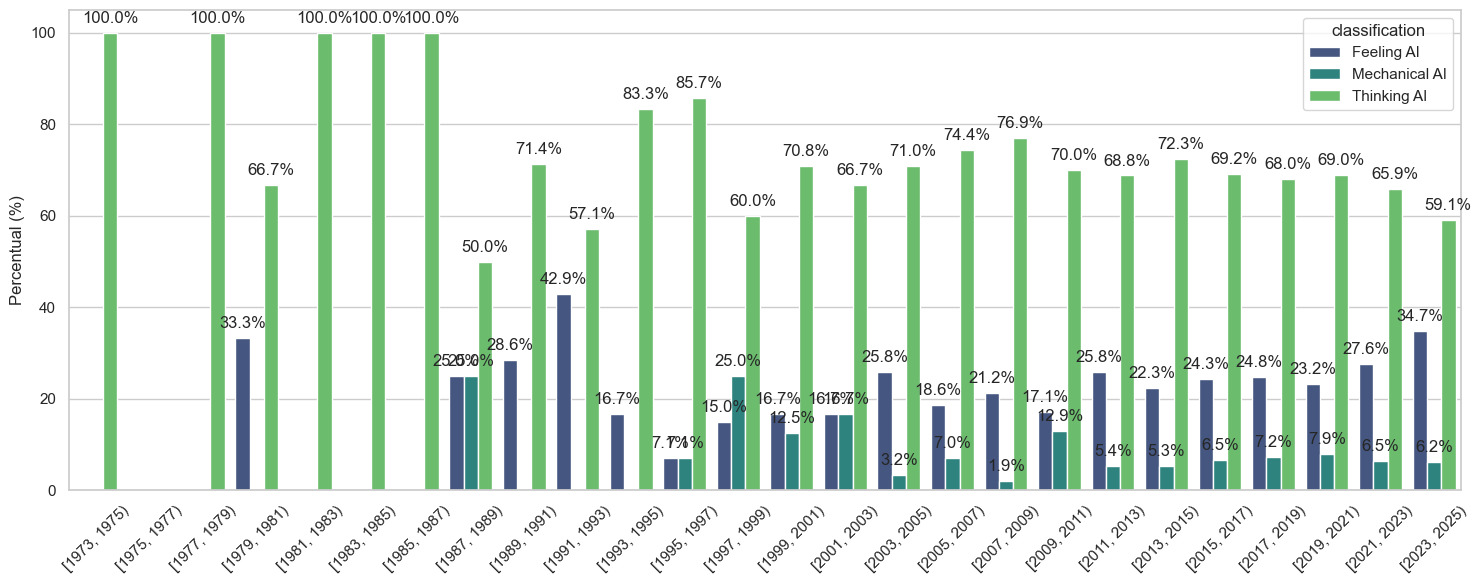

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Agrupando por intervalos de anos
df_all['Year_Group'] = pd.cut(df_all['Year'], 
                              bins=np.arange(df_all['Year'].min(), df_all['Year'].max() + 2, 2), 
                              right=False)

# Contagem e conversão em percentual
count_df = df_all.groupby(['Year_Group', 'classification']).size().reset_index(name='count')
total_per_group = count_df.groupby('Year_Group')['count'].transform('sum')
count_df['percent'] = (count_df['count'] / total_per_group) * 100

# Plot
fig, axs = plt.subplots(1, 1, figsize=(15, 6))
ax = sns.barplot(data=count_df, x='Year_Group', y='percent', hue='classification', palette='viridis', ax=axs)

axs.set_title('')
axs.set_xlabel('')
axs.set_ylabel('Percentual (%)')
plt.xticks(rotation=45)

# Adiciona rótulos de porcentagem
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


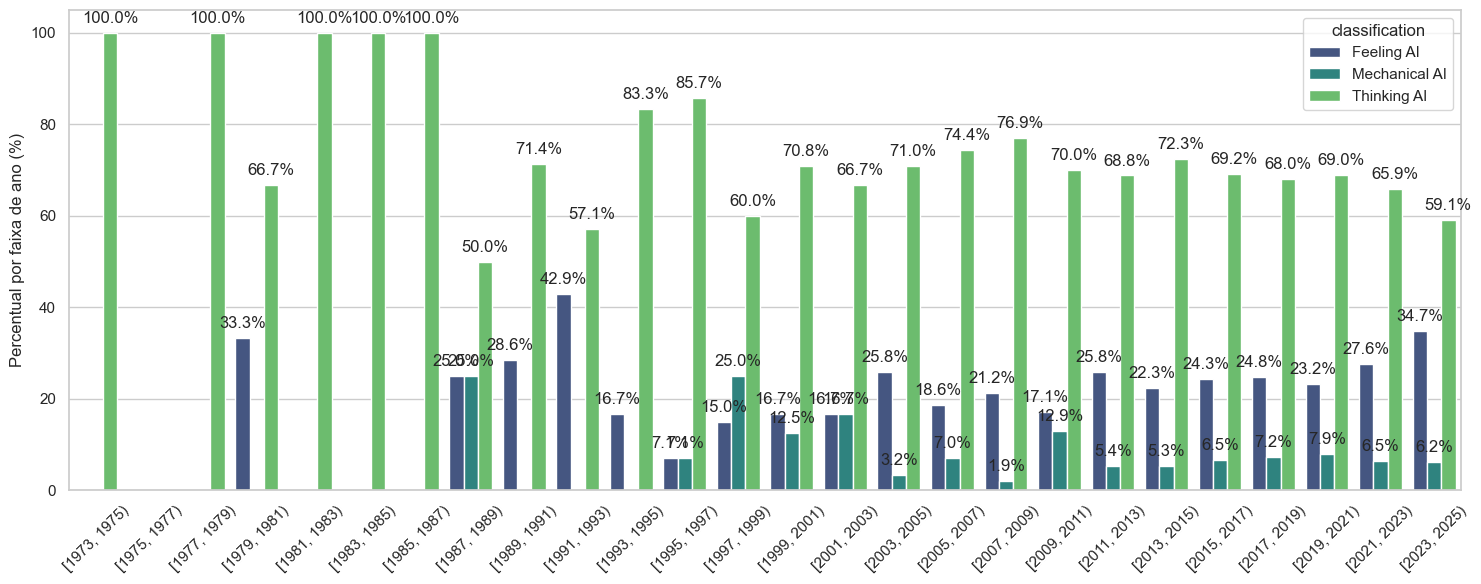

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Agrupar os anos em intervalos
df_all['Year_Group'] = pd.cut(df_all['Year'], 
                              bins=np.arange(df_all['Year'].min(), df_all['Year'].max() + 2, 2), 
                              right=False)

# Contar quantos registros por grupo de ano e classificação
count_df = df_all.groupby(['Year_Group', 'classification']).size().reset_index(name='count')

# Calcular o total por grupo de ano (somando todas as classificações)
total_by_year = count_df.groupby('Year_Group')['count'].transform('sum')

# Calcular o percentual dentro de cada grupo de ano
count_df['percent'] = (count_df['count'] / total_by_year) * 100

# Plotando gráfico de barras com percentuais
fig, axs = plt.subplots(1, 1, figsize=(15, 6))
ax = sns.barplot(data=count_df, x='Year_Group', y='percent', hue='classification', palette='viridis', ax=axs)

axs.set_title('')
axs.set_xlabel('')
axs.set_ylabel('Percentual por faixa de ano (%)')
plt.xticks(rotation=45)

# Adicionar rótulos com percentual em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


In [12]:
df_all['keywords'] = df_all['keywords'].str.replace(r'[\[\]]', '', regex=True)
df_all['keywords'] = df_all['keywords'].str.replace("'","")

                     Keyword  Count
112         Decision support      4
288    Customer segmentation      4
201           Classification      3
46                Automation      2
118                  Pricing      2
409       Internet of things      2
233               E-commerce      2
305         Web usage mining      2
41   Decision support system      2
252             Industry 4.0      2
Mechanical AI


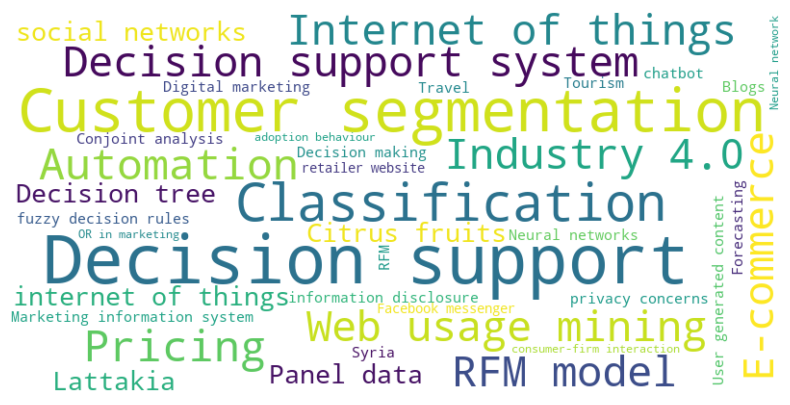

                               Keyword  Count
89                  Marketing strategy     24
146                  Digital marketing     21
272                Marketing analytics     17
487                Market segmentation     16
733                    Decision making     14
1109  Customer relationship management     13
312                 Big data analytics     13
621                  Consumer behavior     13
40                  Business analytics     12
535                            Pricing     12
Thinking AI


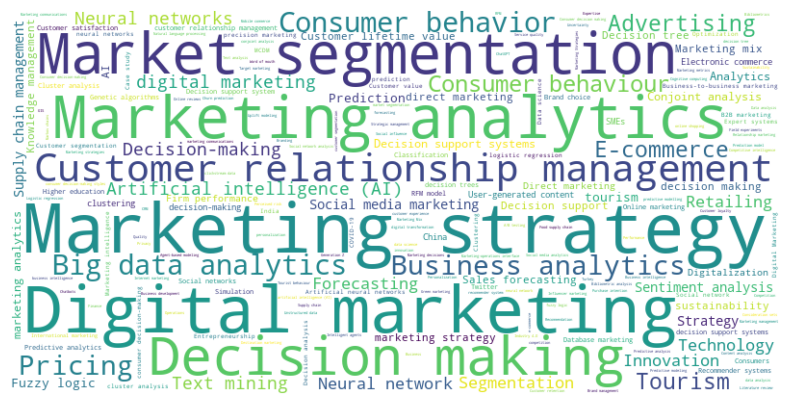

                 Keyword  Count
268   Consumer behaviour     11
283   Sentiment analysis     10
580    Consumer behavior      8
205        Word-of-mouth      7
95       Decision-making      7
77        Neuromarketing      7
328      Decision making      7
28    consumer behaviour      6
1145         Text mining      6
35                 Trust      6
Feeling AI


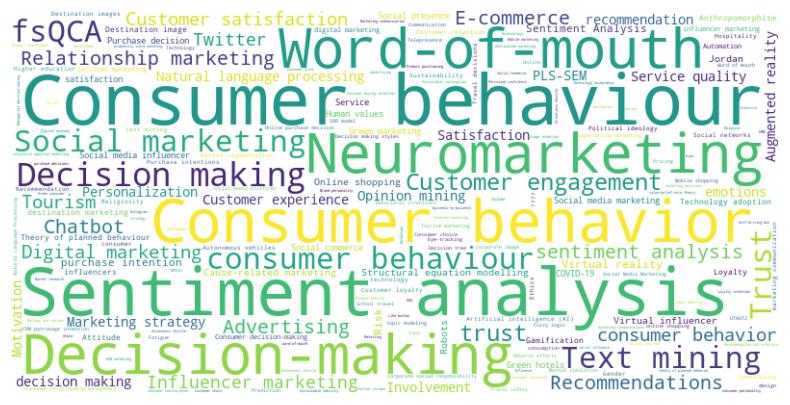

In [7]:
from wordcloud import STOPWORDS

for classification in df_all['classification'].unique():
    df_class = df_all[df_all['classification'].isin([classification])]

    # keywords_series = df_class['keywords'].str.split(',').explode().str.strip()
    keywords_series = df_class['Keywords'].str.split(';').explode().str.strip()
    keyword_counts = Counter(keywords_series)
    keyword_df = pd.DataFrame(keyword_counts.items(), columns=['Keyword', 'Count']).sort_values(by='Count', ascending=False)

    list_remove = ['Marketing', 'Artificial intelligence','Machine learning','Big data','Data mining','Social media','Internet','Facebook','Deep learning']
    keyword_df = keyword_df[~keyword_df["Keyword"].str.lower().isin([x.lower() for x in list_remove])]
    keyword_df.dropna(inplace=True)

    print(keyword_df.head(10))
    keyword_df = keyword_df[keyword_df['Count'] > 1]
    keyword_df.dropna(inplace=True)

    # Criar e exibir a nuvem de palavras a partir do DataFrame
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(
        dict(zip(keyword_df['Keyword'], keyword_df['Count']))
    )

    print(classification)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')    
    plt.show()

In [15]:
df_all[df_all['Keywords'].str.contains('Word-of-mouth',na=False)].sort_values(['Year'],ascending=False).head()


,Title,Authors,Year,DOI,Abstract,Keywords,Publisher,Source,Cited,classification,keywords,rationale,Feeling AI,Mechanical AI,Thinking AI,Out of Scope,Not Identified,Year_Group
167,Virtual or human? The impact of the influencer...,Kholkina V.; Chesnokova E.; Zelenskaya E.,2025,10.1108/JPBM-12-2023-4885,Purpose: Virtual influencers are a growing tre...,Artificial intelligence; Brand attachment; Gen...,Emerald Publishing,scopus-artificial intelligence,1,Feeling AI,"virtual influencers, human influencers, social...",The abstract discusses the impact of virtual a...,60%,10%,30%,0%,0%,NaN
1035,What factors determine the intention to use an...,"Quinones, M; Romero, J; Schmitz, A; Díaz-Martí...",2024,10.1108/EJMBE-07-2023-0224,Purpose - User acceptance is a necessary preco...,Autonomous vehicle; Autonomous shuttle; Driver...,EMERALD GROUP PUBLISHING LTD,wos-autonomous,0,Feeling AI,"user acceptance, trust, word-of-mouth, custome...",The abstract focuses on understanding potentia...,70%,10%,20%,0%,0%,"[2023.0, 2025.0)"
1301,Recommend or not: A comparative analysis of cu...,"Ding, K; Gong, XY; Huang, T; Choo, WC",2024,10.1016/j.iedeen.2023.100236,In the fiercely competitive landscape of the p...,Social marketing; Online recommendation behavi...,ELSEVIER SCI LTD,wos-recommendation,6,Feeling AI,"positive recommendations, negative recommendat...",The abstract focuses on understanding customer...,70%,10%,20%,0%,0%,"[2023.0, 2025.0)"
1392,What factors determine the intention to use an...,Quinones M.; Romero J.; Schmitz A.; Díaz-Martí...,2024,10.1108/EJMBE-07-2023-0224,Purpose: User acceptance is a necessary precon...,Autonomous shuttle; Autonomous vehicle; Driver...,Emerald Publishing,scopus-autonomous,0,Feeling AI,"trust, word-of-mouth, user acceptance, hedonic...",The abstract focuses on user acceptance and th...,70%,10%,20%,0%,0%,"[2023.0, 2025.0)"
1405,"Influentials, early adopters, or random target...",Cui F.; Wang L.; Luo X.R.; Cui X.,2024,10.1016/j.dss.2024.114263,"Product seeding, defined as the act by which f...",Agent-based modeling; Market competition; New ...,Elsevier B.V.,scopus-autonomous,0,Thinking AI,"product seeding, word of mouth, seeding strate...",The abstract discusses the analysis of differe...,0%,0%,100%,0%,0%,"[2023.0, 2025.0)"


## Filtro de Artigos para Análise

In [10]:
df_all['classification'].unique()

array(['Mechanical AI', 'Thinking AI', 'Feeling AI'], dtype=object)

In [12]:
list_topics = [['Decision support','Segmentation','Classification'],
               ['Digital marketing','Marketing analytics', 'Customer relationship management'],
               ['Consumer behaviour','Sentiment analysis','Neuromarketing','Word-of-mouth']]
list_topics[0]
df_all['classification'].unique()[0]

'Mechanical AI'

In [19]:
df_select = pd.DataFrame()
for i in range(0,3):
    df_classification = df_all[df_all['classification'] == df_all['classification'].unique()[i]]
    for topic in list_topics[i]:    
        # Add new articles
        df_ = df_classification[df_classification['Keywords'].str.contains(topic,na=False)].sort_values(['Year'],ascending=False).head(10)
        df_['Topic'] = topic
        df_select = pd.concat([df_select,df_])

        # Add most cited
        df_ = df_classification[df_classification['Keywords'].str.contains(topic,na=False)].sort_values(['Cited'],ascending=False).head(10)
        df_['Topic'] = topic
        df_select = pd.concat([df_select,df_])        
    # display(len(df_classification))
df_select.head()    
    # print(df_all['classification'].unique()[i])
    # print(list_topics[i])    

,Title,Authors,Year,DOI,Abstract,Keywords,Publisher,Source,Cited,classification,keywords,rationale,Feeling AI,Mechanical AI,Thinking AI,Out of Scope,Not Identified,Year_Group,Topic
1861,INTEGRATED SMART INDUSTRY 4.0-BASED DECISION S...,Bagheri H.; Ghavareshki M.H.K.; Abbasi M.; Faz...,2025,10.3934/jimo.2024105,The paper considers a model for an intelligent...,Decision support system; IIntegrated manage; I...,American Institute of Mathematical Sciences,scopus-machine learning,0,Mechanical AI,"['intelligent sales-distribution network', 'de...",The abstract discusses a model for an intellig...,0%,70%,20%,0%,10%,NaN,Decision support
161,A decision support system to evaluate the qual...,Kuik S.; Ban J.; Diong L.; Qi X.,2023,10.1108/TQM-02-2022-0046,Purpose: This paper proposes optimisation mode...,Decision support system; Product remanufacturi...,Emerald Publishing,scopus-artificial intelligence,2,Mechanical AI,"['optimisation models', 'decision support syst...",The abstract discusses the development of opti...,0%,70%,20%,0%,10%,"[2023.0, 2025.0)",Decision support
1667,Performance evaluation for competency of bank ...,Rashid Farooqi M.; Iqbal N.,2019,10.35940/ijrte.A1269.078219,In today's market there is cut throat competit...,Bank telemarketing; Classification; Data minin...,Blue Eyes Intelligence Engineering and Science...,scopus-data mining,10,Mechanical AI,"['data mining', 'telemarketing process', 'data...",The abstract discusses the use of data mining ...,0%,70%,30%,0%,0%,"[2019.0, 2021.0)",Decision support
199,An Adaptive Intelligent Management System of A...,Aguilar J.; Garcia G.,2018,10.1109/TCSS.2017.2759188,"At present, social networks are strongly used ...",Decision support systems; Facebook; intelligen...,Institute of Electrical and Electronics Engine...,scopus-artificial intelligence,22,Mechanical AI,"['automated production', 'data mining', 'autom...",The abstract discusses an intelligent system f...,0%,80%,20%,0%,0%,"[2017.0, 2019.0)",Decision support
333,Semiautomated identification and classificatio...,Choe P.; Lehto M.R.; Shin G.-C.; Choi K.-Y.,2013,10.1002/hfm.20325,This paper examines the feasibility of extract...,Bayesian inference; Call center agent; Custome...,NaN,scopus-prediction,6,Mechanical AI,"['Naïve Bayes classifier', 'customer comments'...",The abstract discusses the use of a Naïve Baye...,0%,70%,20%,0%,10%,"[2013.0, 2015.0)",Decision support


In [21]:
df_select['Topic'].unique()

array(['Decision support', 'Segmentation', 'Classification',
       'Digital marketing', 'Marketing analytics',
       'Customer relationship management', 'Consumer behaviour',
       'Sentiment analysis', 'Neuromarketing', 'Word-of-mouth'],
      dtype=object)

In [24]:
# df_select[df_select['Topic'] == 'Customer relationship management']

In [25]:
# # list_topics = ['Decision support','Segmentation','Classification','Automation','Internet of things',
# #                'Marketing strategy','Digital marketing','Marketing analytics','Customer relationship management','Big data analytics',
# #                'Consumer behaviour','Sentiment analysis','Word-of-mouth','Neuromarketing','Decision making']

# list_topics = ['Decision support','Segmentation','Classification',
#             #    'Marketing strategy','Digital marketing','Marketing analytics',
#                'Digital marketing','Marketing analytics', 'Customer relationship management',
#                'Consumer behaviour','Sentiment analysis','Neuromarketing','Word-of-mouth']

# df_select = pd.DataFrame()
# # df_select['Topic'] = ''
# for topic in list_topics:    
#     # Add new articles
#     df_ = df_all[df_all['Keywords'].str.contains(topic,na=False)].sort_values(['Year'],ascending=False).head(10)
#     df_['Topic'] = topic
#     df_select = pd.concat([df_select,df_])

#     # Add most cited
#     df_ = df_all[df_all['Keywords'].str.contains(topic,na=False)].sort_values(['Cited'],ascending=False).head(10)
#     df_['Topic'] = topic
#     df_select = pd.concat([df_select,df_])
#     # break
# df_select.head()

In [26]:
df_select.to_csv('data/classification/articles_selected.csv', index=False)

In [49]:
df_select = pd.read_csv('data/classification/articles_selected.csv')
df_select.head()

,Title,Authors,Year,DOI,Abstract,Keywords,Publisher,Source,Cited,classification,keywords,rationale,Feeling AI,Mechanical AI,Thinking AI,Out of Scope,Not Identified,Year_Group,Topic
0,INTEGRATED SMART INDUSTRY 4.0-BASED DECISION S...,Bagheri H.; Ghavareshki M.H.K.; Abbasi M.; Faz...,2025,10.3934/jimo.2024105,The paper considers a model for an intelligent...,Decision support system; IIntegrated manage; I...,American Institute of Mathematical Sciences,scopus-machine learning,0,Mechanical AI,"intelligent sales-distribution network, decisi...",The abstract discusses a model for an intellig...,0%,70%,20%,0%,10%,NaN,Word-of-mouth
1,Understanding digitally enabled complex networ...,Gupta S.; Deodhar S.,2024,10.1108/ITP-10-2020-0682,Purpose: Communities representing groups of ag...,Cohesion; Community; Decision support; IT arti...,Emerald Publishing,scopus-recommendation,4,Thinking AI,"community detection, customer trajectory patte...",The abstract discusses a community detection a...,10%,0%,90%,0%,0%,"[2023, 2025)",Word-of-mouth
2,Video marketing for decentralized finance plat...,Giannakopoulos N.T.; Reklitis D.P.; Terzi M.C....,2024,10.1057/s41264-024-00288-2,In the continuously evolving environment of bl...,Big data; Decentralized finance (DeFi); Decisi...,Palgrave Macmillan,scopus-big data,0,Feeling AI,"YouTube metrics, website visibility, campaign ...",The abstract discusses enhancing the digital m...,60%,20%,20%,0%,0%,"[2023, 2025)",Word-of-mouth
3,Video marketing for decentralized finance plat...,"Giannakopoulos, NT; Reklitis, DP; Terzi, MC; S...",2024,10.1057/s41264-024-00288-2,In the continuously evolving environment of bl...,Strategic digital marketing; Video marketing; ...,PALGRAVE MACMILLAN LTD,wos-big data,0,Thinking AI,"DeFi, digital marketing performance, website v...",The abstract discusses the analysis of DeFi Yo...,0%,0%,100%,0%,0%,"[2023, 2025)",Word-of-mouth
4,Unveiling just-in-time decision support system...,Shahidzadeh M.H.; Shokouhyar S.,2024,10.1108/IMDS-12-2023-0921,"Purpose: In recent times, the field of corpora...",Decision support system; Deep learning; Indust...,Emerald Publishing,scopus-recommendation,1,Thinking AI,"social media analytics, strategic decision-mak...",The abstract discusses the use of social media...,0%,0%,100%,0%,0%,"[2023, 2025)",Word-of-mouth


## Traduzir e extrair resumos dos artigos selecionados

In [ ]:
# Imports
import warnings
warnings.filterwarnings('ignore')
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
import time

# Build dynamic prompt (CORREÇÃO: Prompt mais específico e instrução clara de formato)
prompt_template = """
Aja como um assistente de pesquisa para realizar a tarefa de resumo e tradução do inglês para o português.
Você deverá resumir e traduzir o texto abaixo seguindo rigorosamente este formato:

[Texto do resumo aqui]

<Abstract>
{Abstract}
</Abstract>

Forneça apenas o resumo final em português, sem comentários ou formatação.
"""

# Creation of the FewShotPromptTemplate
prompt = PromptTemplate.from_template(prompt_template)

openai_api_key = '<open-ai-key>'  # Substituir pela chave real
modelo = 'gpt-4o-mini'

# Configuração do modelo (CORREÇÃO: Parâmetros otimizados)
llm_openai = ChatOpenAI(
    temperature=0.3,  # Reduzido para mais consistência
    openai_api_key=openai_api_key,
    model=modelo,
    request_timeout=30  # Adicionado timeout
)

llm_chain = prompt | llm_openai

# Controle de execução (CORREÇÃO: Melhor gestão de estado)
class ExecutionControl:
    def __init__(self):
        self.iteration_count = 0
        self.max_retries = 3

control = ExecutionControl()

# Função de processamento (CORREÇÃO: Tratamento de erros e retries)
def query_llm(abstract):
    for attempt in range(control.max_retries):
        try:
            response = llm_chain.invoke({"Abstract": abstract})
            return response.content
        except Exception as e:
            print(f"Erro na tentativa {attempt + 1}: {str(e)}")
            time.sleep(2)
    return "Erro no processamento"

# Função de aplicação (CORREÇÃO: Simplificação e foco na coluna resumo)
def apply_llm(row):
    abstract = row['Abstract']
    response = query_llm(abstract)
    
    control.iteration_count += 1
    row['resumo'] = response  # CORREÇÃO: Atribuição direta à coluna
    
    print(f"Iteração: {control.iteration_count} - Status: {'Sucesso' if response else 'Falha'}")
    return row

# Função de salvamento (CORREÇÃO: Mensagem completa)
def save_to_csv(df):
    df.to_csv('data/classification/artigos_selecionados.csv', index=False)
    print("Arquivo salvo com sucesso")

# Execução principal (CORREÇÃO: Aplicação segura)
try:
    df_select = df_select.apply(apply_llm, axis=1)
    save_to_csv(df_select)
    print('Processamento concluído')
except Exception as e:
    print(f"Erro crítico: {str(e)}")

Iteração: 1 - Status: Sucesso
Iteração: 2 - Status: Sucesso
Iteração: 3 - Status: Sucesso
Iteração: 4 - Status: Sucesso
Iteração: 5 - Status: Sucesso
Iteração: 6 - Status: Sucesso
Iteração: 7 - Status: Sucesso
Iteração: 8 - Status: Sucesso
Iteração: 9 - Status: Sucesso
Iteração: 10 - Status: Sucesso
Iteração: 11 - Status: Sucesso
Iteração: 12 - Status: Sucesso
Iteração: 13 - Status: Sucesso
Iteração: 14 - Status: Sucesso
Iteração: 15 - Status: Sucesso
Iteração: 16 - Status: Sucesso
Iteração: 17 - Status: Sucesso
Iteração: 18 - Status: Sucesso
Iteração: 19 - Status: Sucesso
Iteração: 20 - Status: Sucesso
Iteração: 21 - Status: Sucesso
Iteração: 22 - Status: Sucesso
Iteração: 23 - Status: Sucesso
Iteração: 24 - Status: Sucesso
Iteração: 25 - Status: Sucesso
Iteração: 26 - Status: Sucesso
Iteração: 27 - Status: Sucesso
Iteração: 28 - Status: Sucesso
Iteração: 29 - Status: Sucesso
Iteração: 30 - Status: Sucesso
Iteração: 31 - Status: Sucesso
Iteração: 32 - Status: Sucesso
Iteração: 33 - St